# Customer Segmentation using K-Means Clustering
The objective of this notebook is to segment customers into different groups using K-Means clustering based on their Recency, Frequency, and Monetary (RFM) values. These customer segments help businesses create targeted marketing strategies and improve customer retention.

In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
#Load Dataset
rfm = pd.read_csv("Customer_RFM.csv")

In [3]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,165,11,372.86,2,5,2,252,At Risk
1,3,2,1323.32,5,2,4,524,Others
2,74,1,222.16,2,1,1,211,Others
3,43,3,2671.14,3,3,5,335,Loyal Customers
4,11,1,300.93,5,1,2,512,Others


In [4]:
rfm.shape

(4312, 8)

In [5]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 4312 entries, 0 to 4311
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4312 non-null   int64  
 1   Frequency  4312 non-null   int64  
 2   Monetary   4312 non-null   float64
 3   R_Score    4312 non-null   int64  
 4   F_Score    4312 non-null   int64  
 5   M_Score    4312 non-null   int64  
 6   RFM_Score  4312 non-null   int64  
 7   Segment    4312 non-null   str    
dtypes: float64(1), int64(6), str(1)
memory usage: 306.8 KB


In [6]:
#Select Features
features = rfm[["Recency", "Frequency", "Monetary"]]

In [7]:
features.head()

,Recency,Frequency,Monetary
0,165,11,372.86
1,3,2,1323.32
2,74,1,222.16
3,43,3,2671.14
4,11,1,300.93


In [8]:
#Standardization
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [9]:
scaled_features[:5]

array([[ 0.76229851,  0.80108727, -0.18713934],
       [-0.91040156, -0.3006029 , -0.08047459],
       [-0.17730462, -0.42301292, -0.20405155],
       [-0.4973892 , -0.17819288,  0.07078363],
       [-0.82779909, -0.42301292, -0.19521163]])

In [10]:
#Elbow Method
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

## Cluster Selection

Based on the Elbow Method, 4 clusters were selected as the optimal number of customer groups for segmentation.

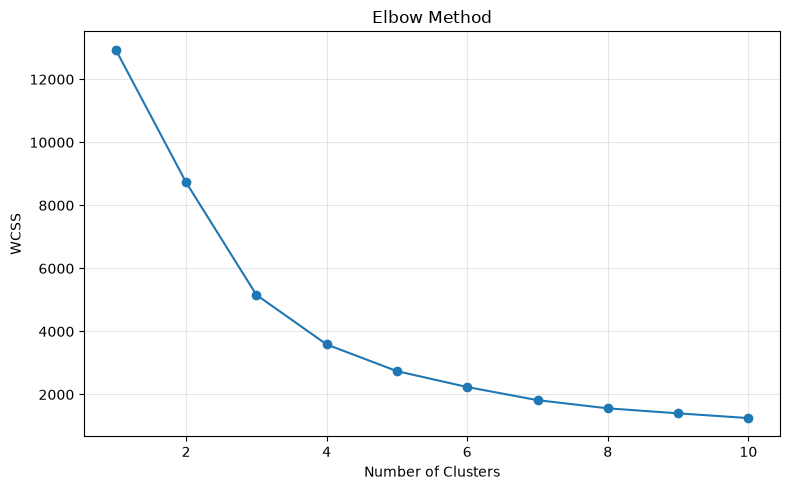

In [11]:
#Elbow Graph
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Business Insight

The Elbow Method helps determine the optimal number of customer clusters by identifying the point where the decrease in WCSS starts to slow down.

In [12]:
#K-Means Model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(scaled_features)

In [13]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
0,165,11,372.86,2,5,2,252,At Risk,1
1,3,2,1323.32,5,2,4,524,Others,0
2,74,1,222.16,2,1,1,211,Others,0
3,43,3,2671.14,3,3,5,335,Loyal Customers,0
4,11,1,300.93,5,1,2,512,Others,0


In [14]:
#Cluster Count
rfm["Cluster"].value_counts()

Cluster
0    3204
1    1047
3      56
2       5
Name: count, dtype: int64

In [15]:
#Silhouette Score
score = silhouette_score(
    scaled_features,
    rfm["Cluster"]
)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.611


In [18]:
#Cluster Summary
cluster_summary = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.03,4.46,1710.65
1,242.98,1.66,593.54
2,5.60,113.60,215535.00
3,14.91,47.02,28896.42


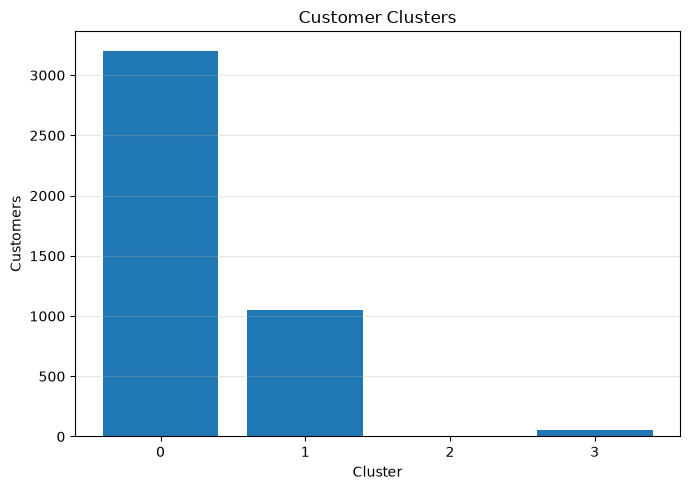

In [17]:
#Cluster Graph
cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Customers")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Business Insight

- Customers are divided into distinct clusters based on their purchasing behavior.
- Each cluster represents customers with different spending patterns.
- Businesses can design personalized marketing campaigns for each customer segment.

In [19]:
rfm.to_csv("Customer_Segments.csv", index=False)

## Conclusion

Customers were successfully segmented using K-Means clustering based on their RFM values.

These customer groups can help businesses design personalized marketing campaigns, improve customer retention, and identify high-value customer segments.